
# E-Commerce Company – End-to-End Data Analysis

**Objective:** Analyze financial performance, customer insights, logistics & fulfillment, product/inventory performance, and customer satisfaction/returns as required by the problem statement.

The problem statement specifically asks for:
- Data exploration and understanding
- Data cleansing, including replacing nulls in **Amount** with the median
- Revenue, customer behavior, logistics, and returns analysis
- Recommendations and conclusion

> **Important data limitation:** The dataset contains an order date and order status, but no shipment date or delivery date. Therefore, actual average shipping time/delivery duration cannot be calculated without inventing data. We use fulfillment and courier-status analysis instead.


In [1]:

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from scipy.stats import mannwhitneyu, chi2_contingency

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [4]:

# 2. UPLOAD DATASET
uploaded = files.upload()

file_name = next(iter(uploaded))
print("Uploaded file:", file_name)

if file_name.lower().endswith('.csv'):
    df = pd.read_csv(file_name, low_memory=False)
elif file_name.lower().endswith(('.xlsx', '.xls')):
    df = pd.read_excel(file_name)
else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Dataset shape:", df.shape)
display(df.head())


Saving sales_dataset.csv to sales_dataset.csv
Uploaded file: sales_dataset.csv
Dataset shape: (128949, 23)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,NaN


In [5]:

# 3. DATA EXPLORATION
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_%": df.isna().mean() * 100
}).sort_values("Missing_Count", ascending=False)
display(missing)

print("\nDuplicate rows:", df.duplicated().sum())
print("Unique Order IDs:", df["Order ID"].nunique())
print("Duplicate Order ID rows:", df["Order ID"].duplicated().sum())


Rows: 128949
Columns: 23

Column names:
['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

Data types:


,dtype
Order ID,object
Date,object
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Style,object
SKU,object
Category,object
Size,object



Missing values:


,Missing_Count,Missing_%
fulfilled-by,89679,69.55
promotion-ids,49142,38.11
Unnamed: 22,49041,38.03
currency,7794,6.04
Amount,7794,6.04
Courier Status,6871,5.33
ship-city,33,0.03
ship-state,33,0.03
ship-postal-code,33,0.03
ship-country,33,0.03



Duplicate rows: 6
Unique Order IDs: 120352
Duplicate Order ID rows: 8597


In [6]:

# 4. DATA CLEANING
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
)

# Remove accidental empty/unnamed columns
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_cols, errors="ignore")

# Convert data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", format="mixed")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce")

# Clean text fields
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# REQUIRED BY PROBLEM STATEMENT:
# Replace missing Amount values with the median
amount_median = df["Amount"].median()
df["Amount"] = df["Amount"].fillna(amount_median)

# Useful analytical flags
return_statuses = {
    "Shipped - Returned to Seller",
    "Shipped - Returning to Seller",
    "Shipped - Rejected by Buyer",
    "Shipped - Lost in Transit",
    "Shipped - Damaged"
}

df["Is_Cancelled"] = df["Status"].eq("Cancelled")
df["Is_Return"] = df["Status"].isin(return_statuses)
df["Is_Successful_or_Active"] = ~df["Is_Cancelled"] & ~df["Is_Return"]

print("Median used for missing Amount:", amount_median)
print("Missing Amount after cleaning:", df["Amount"].isna().sum())
print("Cleaned shape:", df.shape)
display(df.head())


Median used for missing Amount: 605.0
Missing Amount after cleaning: 0
Cleaned shape: (128949, 25)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Is_Cancelled,Is_Return,Is_Successful_or_Active
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,True,False,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,False,True
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,False,False,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,True,False,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,False,False,True


In [7]:

# 5. DATA QUALITY SUMMARY
quality = pd.DataFrame({
    "Metric": [
        "Rows",
        "Unique Orders",
        "Date Start",
        "Date End",
        "Missing Amount After Cleaning",
        "Total Quantity",
        "Unique Categories",
        "Unique SKUs",
        "Unique States"
    ],
    "Value": [
        len(df),
        df["Order ID"].nunique(),
        df["Date"].min().date(),
        df["Date"].max().date(),
        df["Amount"].isna().sum(),
        df["Qty"].sum(),
        df["Category"].nunique(),
        df["SKU"].nunique(),
        df["ship-state"].nunique()
    ]
})
display(quality)


,Metric,Value
0,Rows,128949
1,Unique Orders,120352
2,Date Start,2022-03-31
3,Date End,2022-06-29
4,Missing Amount After Cleaning,0
5,Total Quantity,116651
6,Unique Categories,9
7,Unique SKUs,7195
8,Unique States,69


## 6. Financial Performance Analysis

In [8]:

# Financial KPIs
total_revenue = df["Amount"].sum()
total_orders = df["Order ID"].nunique()
total_units = df["Qty"].sum()
aov = total_revenue / total_orders

non_cancelled_revenue = df.loc[~df["Is_Cancelled"], "Amount"].sum()
successful_revenue = df.loc[df["Is_Successful_or_Active"], "Amount"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Recorded Revenue",
        "Unique Orders",
        "Total Units",
        "Average Order Value",
        "Non-Cancelled Revenue",
        "Successful/Active Revenue",
        "Cancellation Rate"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_units,
        aov,
        non_cancelled_revenue,
        successful_revenue,
        df["Is_Cancelled"].mean() * 100
    ]
})
display(kpis)


,KPI,Value
0,Total Recorded Revenue,"83,290,542.94"
1,Unique Orders,"120,352.00"
2,Total Units,"116,651.00"
3,Average Order Value,692.06
4,Non-Cancelled Revenue,"71,788,808.62"
5,Successful/Active Revenue,"70,399,301.62"
6,Cancellation Rate,14.22


,Date,Orders,Units,Revenue,Month
0,2022-03,158,156,"107,128.85",2022-03
1,2022-04,45849,44210,"30,647,735.96",2022-04
2,2022-05,39216,38016,"27,737,127.75",2022-05
3,2022-06,35129,34269,"24,798,550.38",2022-06


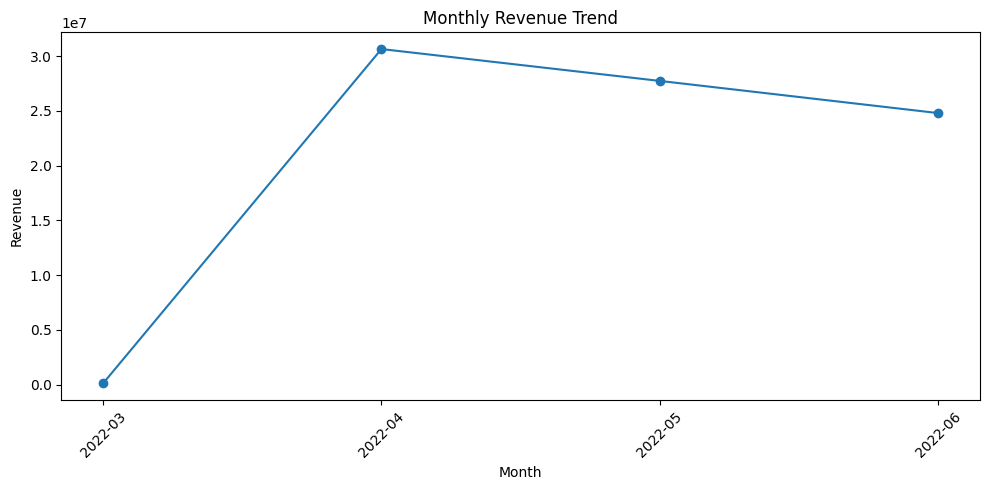

Peak revenue day: 2022-05-04
Peak day revenue: 1298904.17


In [9]:

# Monthly revenue trend
monthly = (
    df.groupby(df["Date"].dt.to_period("M"))
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum")
      )
      .reset_index()
)
monthly["Month"] = monthly["Date"].astype(str)

display(monthly)

plt.figure(figsize=(10,5))
plt.plot(monthly["Month"], monthly["Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Daily revenue – identify peak sales day
daily = df.groupby("Date").agg(
    Orders=("Order ID", "nunique"),
    Units=("Qty", "sum"),
    Revenue=("Amount", "sum")
).reset_index()

peak_day = daily.loc[daily["Revenue"].idxmax()]
print("Peak revenue day:", peak_day["Date"].date())
print("Peak day revenue:", peak_day["Revenue"])


## 7. Product & Inventory Analysis

,Orders,Units,Revenue,Cancelled,Returned,Cancellation_Rate_%,Return_Rate_%
Category,,,,,,,
Set,47836,45288,"41,157,496.67",7338,847,14.60,1.68
kurta,46551,45049,"23,206,327.70",7259,754,14.56,1.51
Western Dress,14989,13943,"11,694,003.69",2125,345,13.71,2.23
Top,10154,9902,"5,623,727.30",1276,134,12.01,1.26
Ethnic Dress,1147,1052,"830,292.66",146,16,12.61,1.38
Blouse,897,864,"485,633.18",116,12,12.53,1.30
Bottom,410,398,"162,767.98",60,6,13.64,1.36
Saree,144,152,"129,378.76",21,1,12.80,0.61
Dupatta,2,3,915.00,0,0,0.00,0.00


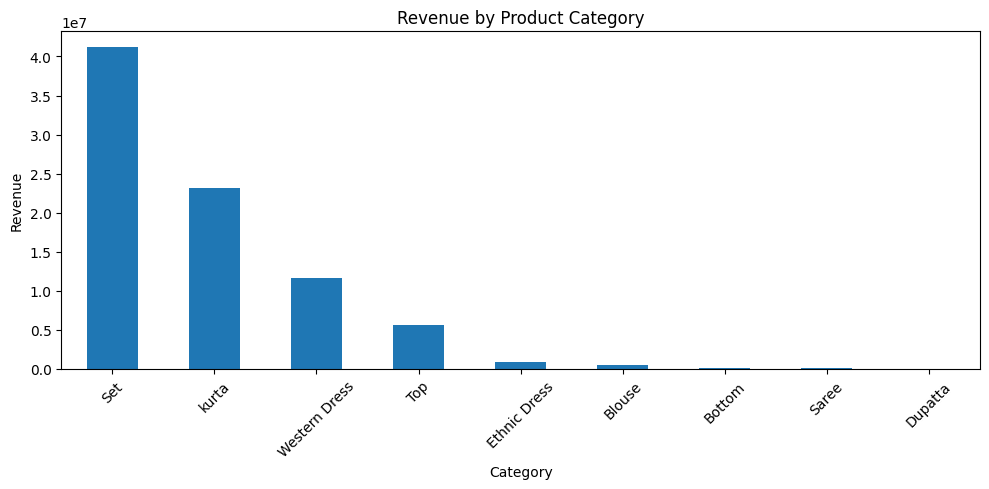

,,,Orders,Units,Revenue
SKU,Style,Category,,,
JNE3797-KR-L,JNE3797,Western Dress,773,661,"555,436.77"
J0230-SKD-M,J0230,Set,506,469,"548,874.20"
J0230-SKD-S,J0230,Set,452,421,"494,457.14"
JNE3797-KR-M,JNE3797,Western Dress,657,561,"476,070.16"
JNE3797-KR-S,JNE3797,Western Dress,587,503,"427,872.57"
JNE3797-KR-XL,JNE3797,Western Dress,474,416,"349,095.24"
J0230-SKD-L,J0230,Set,297,272,"318,926.95"
JNE3797-KR-XS,JNE3797,Western Dress,431,386,"318,136.70"
SET268-KR-NP-XL,SET268,Set,386,373,"292,528.96"


In [10]:

# Category performance
category = (
    df.groupby("Category")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum"),
          Cancelled=("Is_Cancelled", "sum"),
          Returned=("Is_Return", "sum")
      )
)
category["Cancellation_Rate_%"] = category["Cancelled"] / df.groupby("Category").size() * 100
category["Return_Rate_%"] = category["Returned"] / df.groupby("Category").size() * 100
category = category.sort_values("Revenue", ascending=False)

display(category.round(2))

plt.figure(figsize=(10,5))
category["Revenue"].plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 10 SKUs
top_skus = (
    df.groupby(["SKU", "Style", "Category"])
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)
display(top_skus.round(2))


## 8. Customer & Location Insights

,Orders,Units,Revenue
ship-state,,,
MAHARASHTRA,20777,20326,"14,051,391.14"
KARNATAKA,16177,15901,"11,041,795.37"
TELANGANA,10402,10255,"7,333,985.65"
UTTAR PRADESH,10060,9497,"7,232,467.08"
TAMIL NADU,10517,10414,"6,921,696.11"
DELHI,6357,6155,"4,469,778.97"
KERALA,6105,5815,"4,092,797.58"
WEST BENGAL,5652,5316,"3,758,705.44"
ANDHRA PRADESH,4978,4819,"3,446,162.72"


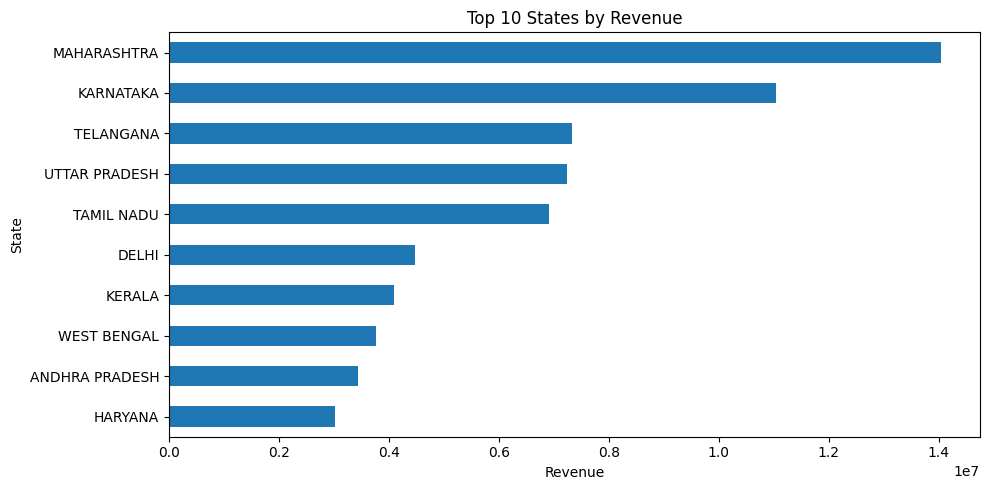

,Orders,Revenue
ship-city,,
BENGALURU,10452,"7,168,345.99"
HYDERABAD,7408,"5,227,277.82"
MUMBAI,5653,"3,859,728.80"
NEW DELHI,5434,"3,821,817.78"
CHENNAI,4923,"3,273,076.74"
PUNE,3593,"2,458,668.18"
KOLKATA,2249,"1,497,258.87"
GURUGRAM,1770,"1,272,493.74"
THANE,1613,"1,061,225.29"


,Orders,Units,Revenue,AOV
B2B,,,,
False,119558,115810,"82,682,382.15",691.57
True,794,841,"608,160.79",765.95


Mann-Whitney U test
B2B mean order value: 765.9455793450882
B2C mean order value: 691.5671234881814
p-value: 6.154842087981105e-07
Conclusion: B2B and B2C order values are statistically different at the 5% significance level.


In [11]:

# State-level performance
state_perf = (
    df.groupby("ship-state")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

display(state_perf.head(10).round(2))

plt.figure(figsize=(10,5))
state_perf.head(10)["Revenue"].sort_values().plot(kind="barh")
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# City-level performance
city_perf = (
    df.groupby("ship-city")
      .agg(
          Orders=("Order ID", "nunique"),
          Revenue=("Amount", "sum")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)
display(city_perf.round(2))

# B2B vs B2C
b2b = (
    df.groupby("B2B")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum")
      )
)
b2b["AOV"] = b2b["Revenue"] / b2b["Orders"]
display(b2b.round(2))

# Statistical test: B2B vs B2C order value
order_level = (
    df.groupby(["Order ID", "B2B"], as_index=False)
      .agg(Order_Value=("Amount", "sum"))
)

b2b_values = order_level.loc[order_level["B2B"], "Order_Value"]
b2c_values = order_level.loc[~order_level["B2B"], "Order_Value"]

u_stat, p_value = mannwhitneyu(b2b_values, b2c_values, alternative="two-sided")

print("Mann-Whitney U test")
print("B2B mean order value:", b2b_values.mean())
print("B2C mean order value:", b2c_values.mean())
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: B2B and B2C order values are statistically different at the 5% significance level.")
else:
    print("Conclusion: No statistically significant difference detected at the 5% significance level.")


## 9. Logistics & Fulfillment Optimization

In [12]:

# Fulfillment comparison
fulfillment = (
    df.groupby("Fulfilment")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Qty", "sum"),
          Revenue=("Amount", "sum"),
          Cancelled=("Is_Cancelled", "sum"),
          Returned=("Is_Return", "sum")
      )
)
fulfillment["AOV"] = fulfillment["Revenue"] / fulfillment["Orders"]
fulfillment["Cancellation_Rate_%"] = fulfillment["Cancelled"] / df.groupby("Fulfilment").size() * 100
fulfillment["Return_Rate_%"] = fulfillment["Returned"] / df.groupby("Fulfilment").size() * 100

display(fulfillment.round(2))

# Shipping service level
service = (
    df.groupby("ship-service-level")
      .agg(
          Orders=("Order ID", "nunique"),
          Revenue=("Amount", "sum"),
          Units=("Qty", "sum"),
          Cancelled=("Is_Cancelled", "sum")
      )
)
service["AOV"] = service["Revenue"] / service["Orders"]
service["Cancellation_Rate_%"] = service["Cancelled"] / df.groupby("ship-service-level").size() * 100
display(service.round(2))

# Courier status
courier = pd.crosstab(df["Fulfilment"], df["Courier Status"], normalize="index") * 100
display(courier.round(2))

# IMPORTANT LIMITATION
print("LIMITATION:")
print("Actual average shipping time cannot be calculated because shipment/delivery date fields are not present.")
print("Use fulfillment, service level and courier status as operational proxies.")


,Orders,Units,Revenue,Cancelled,Returned,AOV,Cancellation_Rate_%,Return_Rate_%
Fulfilment,,,,,,,,
Amazon,83983,84086,"57,974,543.00",11479,0,690.31,12.80,0.00
Merchant,36369,32565,"25,315,999.94",6862,2115,696.09,17.47,5.39


,Orders,Revenue,Units,Cancelled,AOV,Cancellation_Rate_%
ship-service-level,,,,,,
Expedited,82903,"57,836,540.00",83001,11431,697.64,12.90
Standard,37449,"25,454,002.94",33650,6910,679.70,17.12


Courier Status,Cancelled,Shipped,Unshipped
Fulfilment,,,
Amazon,6.62,86.52,6.87
Merchant,0.00,98.38,1.62


LIMITATION:
Actual average shipping time cannot be calculated because shipment/delivery date fields are not present.
Use fulfillment, service level and courier status as operational proxies.


## 10. Customer Satisfaction, Cancellation & Returns

,Orders,Percentage
Status,,
Shipped,77767,60.31
Shipped - Delivered to Buyer,28771,22.31
Cancelled,18341,14.22
Shipped - Returned to Seller,1953,1.51
Shipped - Picked Up,973,0.75
Pending,658,0.51
Pending - Waiting for Pick Up,281,0.22
Shipped - Returning to Seller,145,0.11
Shipped - Out for Delivery,35,0.03


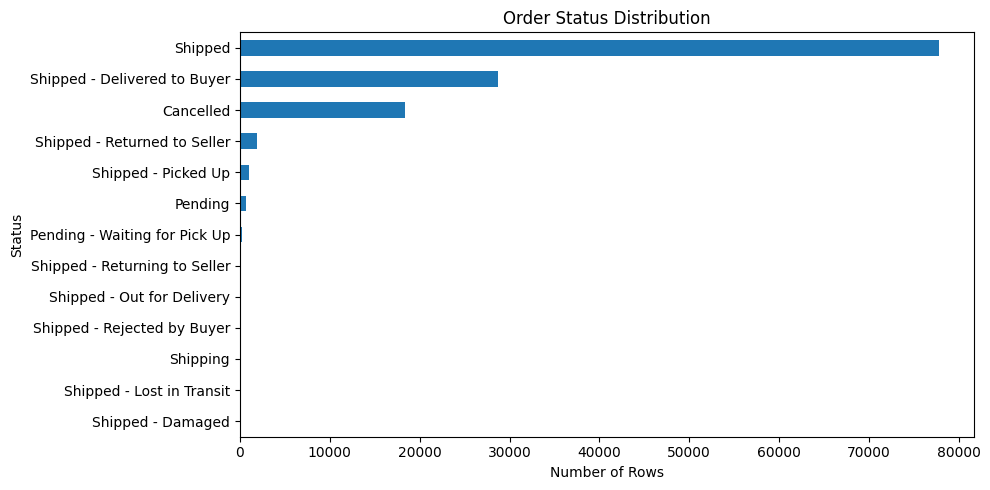

,Cancellation_Rate_%,Return_Rate_%
Category,,
Set,14.60,1.68
kurta,14.56,1.51
Western Dress,13.71,2.23
Bottom,13.64,1.36
Saree,12.80,0.61
Ethnic Dress,12.61,1.38
Blouse,12.53,1.30
Top,12.01,1.26
Dupatta,0.00,0.00


Cancellation rate by fulfillment:


,Cancellation_Rate_%
Fulfilment,
Amazon,12.80
Merchant,17.47


Cancellation rate by shipping service:


,Cancellation_Rate_%
ship-service-level,
Expedited,12.90
Standard,17.12


In [13]:

# Overall status distribution
status_summary = (
    df["Status"]
      .value_counts()
      .to_frame("Orders")
)
status_summary["Percentage"] = status_summary["Orders"] / len(df) * 100
display(status_summary.round(2))

plt.figure(figsize=(10,5))
status_summary["Orders"].sort_values().plot(kind="barh")
plt.title("Order Status Distribution")
plt.xlabel("Number of Rows")
plt.ylabel("Status")
plt.tight_layout()
plt.show()

# Category-level cancellation and return rates
problem_categories = category[
    ["Cancellation_Rate_%", "Return_Rate_%"]
].sort_values("Cancellation_Rate_%", ascending=False)

display(problem_categories.round(2))

# Cancellation by fulfillment and service level
print("Cancellation rate by fulfillment:")
display((df.groupby("Fulfilment")["Is_Cancelled"].mean() * 100).round(2).to_frame("Cancellation_Rate_%"))

print("Cancellation rate by shipping service:")
display((df.groupby("ship-service-level")["Is_Cancelled"].mean() * 100).round(2).to_frame("Cancellation_Rate_%"))


## 11. Promotion Analysis

In [14]:

promo_flag = (
    df["promotion-ids"].notna() &
    df["promotion-ids"].astype(str).str.strip().ne("")
)

promotion = pd.DataFrame({
    "Group": ["Promotion Present", "No Promotion"],
    "Orders": [
        df.loc[promo_flag, "Order ID"].nunique(),
        df.loc[~promo_flag, "Order ID"].nunique()
    ],
    "Revenue": [
        df.loc[promo_flag, "Amount"].sum(),
        df.loc[~promo_flag, "Amount"].sum()
    ]
})
promotion["AOV"] = promotion["Revenue"] / promotion["Orders"]
display(promotion.round(2))


,Group,Orders,Revenue,AOV
0,Promotion Present,73449,"53,784,322.00",732.27
1,No Promotion,46926,"29,506,220.94",628.78


## 12. Key Findings & Recommendations

In [15]:

# Automatically print headline findings
top_category = category.index[0]
top_state = state_perf.index[0]
top_city = city_perf.index[0]
top_fulfillment = fulfillment["Revenue"].idxmax()

cancel_rate = df["Is_Cancelled"].mean() * 100
return_rate = df["Is_Return"].mean() * 100

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Highest-revenue product category: {top_category}")
print(f"2. Highest-revenue state: {top_state}")
print(f"3. Highest-revenue city among listed cities: {top_city}")
print(f"4. Highest-revenue fulfillment method: {top_fulfillment}")
print(f"5. Overall cancellation rate: {cancel_rate:.2f}%")
print(f"6. Overall return/problem-status rate: {return_rate:.2f}%")
print(f"7. Median Amount used for missing-value imputation: {amount_median:.2f}")

print("\nRECOMMENDATIONS")
print("-" * 70)
print("1. Focus inventory and marketing on high-revenue categories and SKUs.")
print("2. Investigate cancellation drivers, especially across fulfillment and shipping service levels.")
print("3. Strengthen inventory planning for high-demand categories to reduce stockout/overstock risk.")
print("4. Prioritize high-revenue states/cities for targeted campaigns and localized inventory.")
print("5. Compare Amazon and Merchant fulfillment operationally and investigate the higher-cancellation process.")
print("6. Use courier-status monitoring to identify unshipped/cancelled orders early.")
print("7. Actual customer retention should be analyzed after adding a customer identifier.")
print("8. Actual shipping-time analysis should be performed after adding shipment and delivery timestamps.")


KEY FINDINGS
----------------------------------------------------------------------
1. Highest-revenue product category: Set
2. Highest-revenue state: MAHARASHTRA
3. Highest-revenue city among listed cities: BENGALURU
4. Highest-revenue fulfillment method: Amazon
5. Overall cancellation rate: 14.22%
6. Overall return/problem-status rate: 1.64%
7. Median Amount used for missing-value imputation: 605.00

RECOMMENDATIONS
----------------------------------------------------------------------
1. Focus inventory and marketing on high-revenue categories and SKUs.
2. Investigate cancellation drivers, especially across fulfillment and shipping service levels.
3. Strengthen inventory planning for high-demand categories to reduce stockout/overstock risk.
4. Prioritize high-revenue states/cities for targeted campaigns and localized inventory.
5. Compare Amazon and Merchant fulfillment operationally and investigate the higher-cancellation process.
6. Use courier-status monitoring to identify unship


## 13. Final Conclusion

The analysis combines data cleaning, exploratory analysis, KPI calculation, time-based revenue analysis, product/category analysis, geographic analysis, B2B vs B2C segmentation, fulfillment comparison, cancellation/return analysis, and statistical testing.

The strongest business actions are to:
- optimize inventory around high-demand/high-revenue products,
- reduce cancellations and returns,
- improve fulfillment monitoring,
- target high-performing geographies,
- and continuously track revenue, AOV, cancellation rate, return rate, fulfillment performance and product demand.

**Data limitations to mention in the final submission:** no customer ID is available for true retention analysis, and no shipment/delivery dates are available for calculating actual shipping duration.
